**STUDY CASE 3 - RETAIL PRICING**

**SAINS DATA PADA INDUSTRI**

Kelompok 7
1. Justin Jeremia - 103052330106
2. Annisa Azzahra Rahmah - 103052300056
3. Eliezer Sharon Hutabarat - 103052300090
4. Amalia Ananda Putri - 103052330078

DS - 47 - 01


---






# **1. Import Library dan Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/clothes_price_prediction_data.csv")
df.head()

,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113


# **2. EDA (Exploratory Data Analysis)**

## 2.1 Informasi Dataset

In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (1000, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     1000 non-null   object
 1   Category  1000 non-null   object
 2   Color     1000 non-null   object
 3   Size      1000 non-null   object
 4   Material  1000 non-null   object
 5   Price     1000 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


Dataset terdiri dari 1000 baris dan 6 kolom.

## 2.2 Missing Value dan Data Duplikat

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Brand       0
Category    0
Color       0
Size        0
Material    0
Price       0
dtype: int64


Dari hasil terlihat bahwa tidak terdapat missing value pada dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

Dari hasil terlihat bahwa tidak ada data duplikat pada dataset.

## 2.3 Statistik Deskriptif Dataset

In [ ]:
print("\nDescriptive Stats:")
print(df.describe())


Descriptive Stats:
             Price
count  1000.000000
mean    106.289000
std      53.695444
min      10.000000
25%      59.750000
50%     108.000000
75%     150.000000
max     199.000000


Dari hasil terlihat bahwa:
- Rata-rata data sekitar 106.29.
- Nilai harga yang paling rendah adalah 10 dan paling tinggi 199.
- Standar deviasi data sekitar 53.70 yang berarti variasi harga cukup besar sehingga data tersebar dan tidak terlalu mengumpul di rata-rata.

## 2.4 Distribusi Data Target (Price)

/tmp/ipykernel_3772/599115124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Price_Category', data=df, palette='Blues')


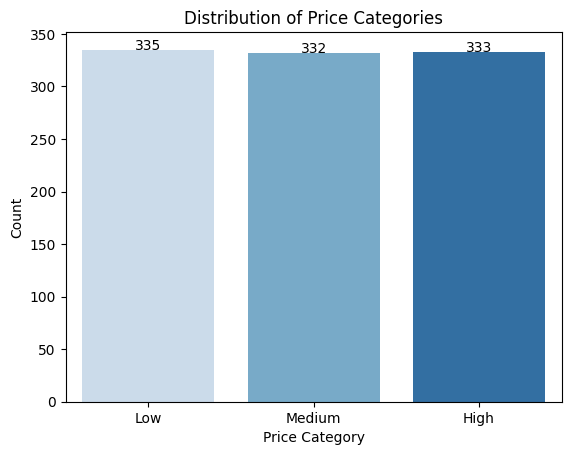

In [ ]:
plt.figure()
# Kategori harga (low, medium, high)
df['Price_Category'] = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])

sns.countplot(x='Price_Category', data=df, palette='Blues')

ax = plt.gca()
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(),
            int(p.get_height()), ha='center')

plt.title("Distribution of Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.show()

Dari hasil di atas terlihat bahwa data harga (price) terbagi cukup merata antara kategori low, medium, dan high sehingga tidak ada dominasi di salah satu kategori harga (distribusi price seimbang).

## 2.5 Rata-Rata Harga per Brand

/tmp/ipykernel_3772/3811847632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_price.values, y=brand_price.index, palette='Blues')


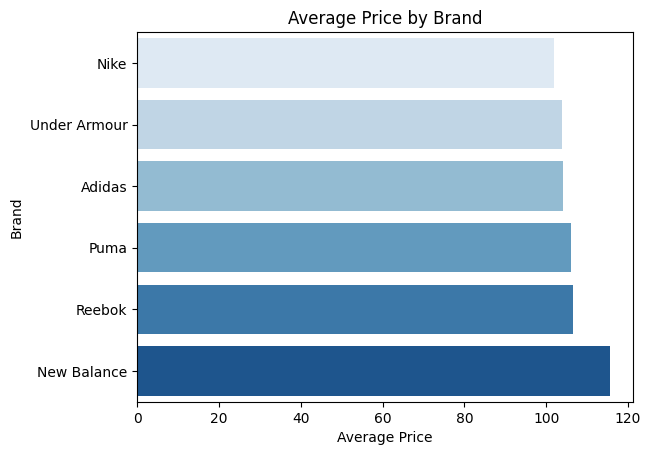

In [ ]:
plt.figure()
brand_price = df.groupby('Brand')['Price'].mean().sort_values()

sns.barplot(x=brand_price.values, y=brand_price.index, palette='Blues')
plt.title("Average Price by Brand")
plt.xlabel("Average Price")
plt.ylabel("Brand")
plt.show()

Dari hasil di atas, terlihat bahwa New Balance memiliki rata-rata harga yang paling tinggi (mahal) dibandingkan dengan brand-brand lain. Sedangkan, Nike memiliki rata-rata harga yang paling rendah (murah). Perbedaan harga antar brand tidak terlalu jauh, tetapi tetap terlihat variasi kecil di antaranya.

## 2.6 Rata-Rata Harga per Kategori

/tmp/ipykernel_3772/721985217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_price.values, y=cat_price.index, palette='Blues' )


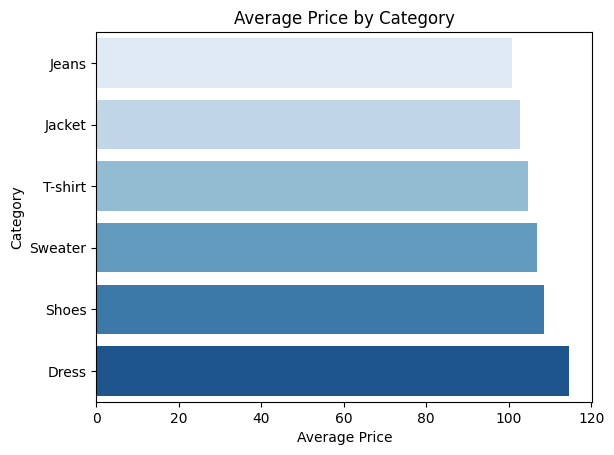

In [ ]:
plt.figure()
cat_price = df.groupby('Category')['Price'].mean().sort_values()

sns.barplot(x=cat_price.values, y=cat_price.index, palette='Blues' )
plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.show()

Dari hasil di atas, terlihat bahwa pakaian dengan kategori Dress memiliki rata-rata harga yang paling tinggi (mahal) dibandingkan dengan kategori pakaian yang lain. Sedangkan, pakaian dengan kategori Jeans memiliki rata-rata harga yang paling rendah (murah).

## 2.7 Rata-Rata Harga berdasarkan Size Pakaian

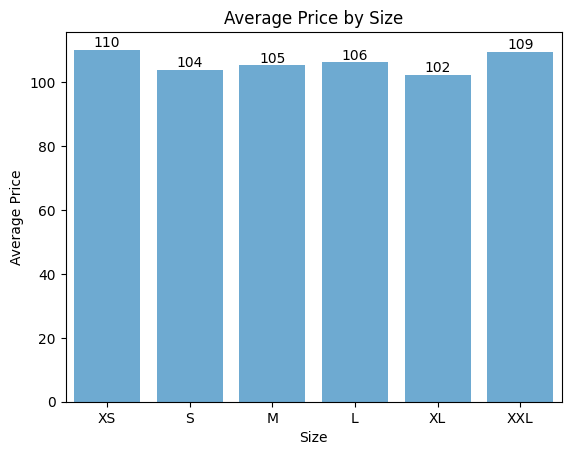

In [ ]:
plt.figure()
size_price = df.groupby('Size')['Price'].mean().reindex(['XS','S','M','L','XL','XXL'])

ax = sns.barplot(
    x=size_price.index,
    y=size_price.values,
    color='#5DADE2'
)

for i, v in enumerate(size_price.values):
    ax.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.title("Average Price by Size")
plt.xlabel("Size")
plt.ylabel("Average Price")
plt.show()

Dari hasil terlihat bahwa ukuran (size) pakaian tidak terlalu berpengaruh signifikan terhadap harga. Rata-rata harga tiap size berada di kisaran yang hampir sama, yaitu sekitar 102–110.

## 2.8 Rata-Rata Harga berdasarkan Material Pakaian

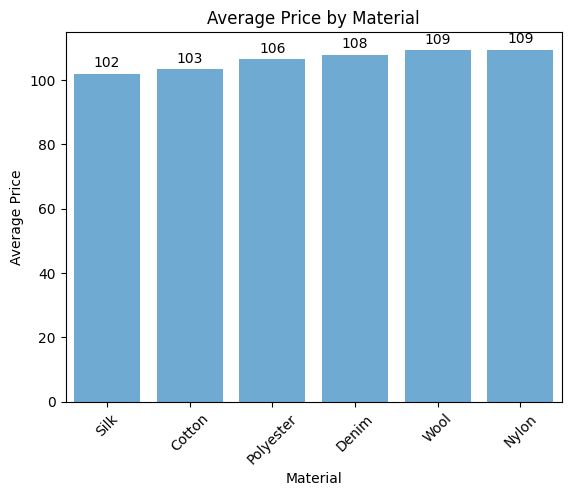

In [ ]:
plt.figure()
material_price = df.groupby('Material')['Price'].mean().sort_values()

ax = sns.barplot(
    x=material_price.index,
    y=material_price.values,
    color='#5DADE2'
)

for i, v in enumerate(material_price.values):
    ax.text(i, v + 0.02*v, f"{v:.0f}", ha='center')

plt.title("Average Price by Material")
plt.xlabel("Material")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

Dari hasil di atas terlihat bahwa jenis material pakaian hanya memberikan pengaruh yang kecil terhadap harga. Rata-rata harga tiap material pakaian hampir sama, yaitu sekitar 102–109.

Material seperti wool dan nylon memiliki harga sedikit lebih tinggi, sedangkan silk dan cotton sedikit lebih rendah. Namun, perbedaannya tidak terlalu jauh sehingga harga relatif stabil di berbagai jenis material.

## 2.9 Pengaruh Kombinasi Brand dan Material terhadap Harga

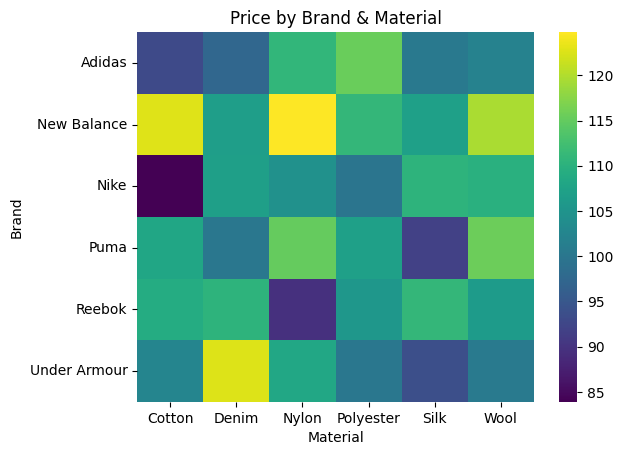

In [ ]:
plt.figure()
combo = df.groupby(['Brand','Material'])['Price'].mean().reset_index()

pivot_table = combo.pivot(index='Brand', columns='Material', values='Price')

sns.heatmap(pivot_table, cmap='viridis')
plt.title("Price by Brand & Material")
plt.show()

Dari hasil terlihat bahwa bahwa kombinasi brand dan material mempengaruhi harga. Terlihat tiap brand mempunyai variasi harga yang berbeda tergantung materialnya, misalnya New Balance cenderung memiliki harga yang tinggi di hampir semua material, terutama Nylon dan Cotton.

Dibandingkan dilihat secara terpisah, pengaruh brand dan material lebih terlihat jelas terhadap harga karena ada kombinasi tertentu yang membuat harga jadi lebih tinggi atau lebih rendah.

# **3. Cek Data Kategorikal**

In [ ]:
categorical_cols = ['Brand', 'Category', 'Color', 'Size', 'Material']

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Brand value counts:
Brand
Under Armour    179
Puma            168
Adidas          166
Nike            165
New Balance     164
Reebok          158
Name: count, dtype: int64

Category value counts:
Category
Jacket     191
Shoes      172
Jeans      167
Dress      166
Sweater    160
T-shirt    144
Name: count, dtype: int64

Color value counts:
Color
Yellow    173
White     171
Red       168
Black     163
Blue      163
Green     162
Name: count, dtype: int64

Size value counts:
Size
XS     196
XXL    173
XL     167
S      166
M      157
L      141
Name: count, dtype: int64

Material value counts:
Material
Polyester    175
Silk         173
Wool         172
Denim        163
Cotton       162
Nylon        155
Name: count, dtype: int64


Dari output yang dihasilkan, terlihat bahwa semua kolom memiliki distribusi yang cukup seimbang. Pada kolom Brand, jumlah data tiap merek berkisar antara 158 sampai 179, jadi tidak ada brand yang mendominasi. Hal ini berarti model tidak akan terbias ke satu brand tertentu saja.

Pada kolom Category, nilai tertinggi ada di Jacket (191) dan terendah di T-shirt (144). Selisihnya masih wajar sehingga semua kategori masih terwakili cukup baik di data.

Untuk Color, semua warna berada di rentang 162–173 yang berarti hampir benar-benar merata. Ini menunjukkan bahwa warna kemungkinan bukan faktor yang terlalu membedakan data karena distribusinya sangat seragam.

Di Size, ukuran XS (196) paling banyak dan L (141) paling sedikit. Dari sini terlihat ada sedikit perbedaan preferensi ukuran walaupun belum terlalu ekstrem.

Terakhir, pada Material, Polyester (175) paling sering muncul dan Nylon (155) paling sedikit. Distribusinya juga masih relatif seimbang sehingga semua material cukup terwakili di data.

# **4. Data Preprocessing (Encoding)**

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

# One-hot encoding untuk semua fitur kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# **5. Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **6. Pipeline Ridge Regression**

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)

# **7. Pipeline XGBoost**

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

# **8. Evaluasi Model**

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n=== {model_name} ===")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate_model(y_test, ridge_pred, "Ridge Regression")
evaluate_model(y_test, xgb_pred, "XGBoost")


=== Ridge Regression ===
MAE: 46.321988024201715
RMSE: 54.1294980598075
R2 Score: 0.0001689865788402356

=== XGBoost ===
MAE: 47.73702621459961
RMSE: 56.41752830459697
R2 Score: -0.08614242076873779


Kode tersebut digunakan untuk mengevaluasi performa dua model, yaitu Ridge Regression dan XGBoost, menggunakan tiga metrik: MAE, RMSE, dan R². Hasilnya menunjukkan bahwa Ridge Regression memiliki MAE sekitar 46,32 dan RMSE sekitar 54,13, sedangkan XGBoost memiliki MAE sekitar 47,74 dan RMSE sekitar 56,42. Ini berarti rata-rata kesalahan prediksi kedua model cukup besar, dengan Ridge sedikit lebih baik dibanding XGBoost.

# **9. Perbandingan Hasil**

In [ ]:
results = pd.DataFrame({
    'Model': ['Ridge', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    'R2': [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Ridge,46.321988,54.129498,0.000169
1,XGBoost,47.737026,56.417528,-0.086142


Pada bagian ini, hasil evaluasi kedua model dirangkum dalam bentuk tabel agar lebih mudah dibandingkan secara langsung. Ridge Regression memiliki MAE sebesar 46,32 dan RMSE sebesar 54,13, sedangkan XGBoost memiliki MAE sebesar 47,74 dan RMSE sebesar 56,42. Ini menunjukkan bahwa Ridge menghasilkan error yang lebih kecil dibandingkan XGBoost, sehingga secara numerik performanya sedikit lebih baik.

Namun, jika dilihat dari nilai R², Ridge hanya memperoleh sekitar 0,00017 yang berarti hampir tidak mampu menjelaskan variasi data, sementara XGBoost bahkan memiliki nilai R² negatif (-0,086) yang menandakan performanya lebih buruk dibandingkan prediksi sederhana menggunakan rata-rata.

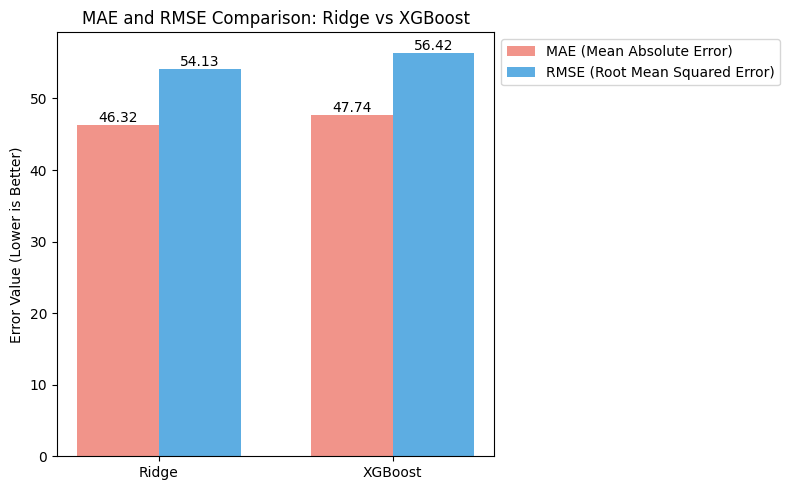

In [ ]:
models = results['Model']
mae = results['MAE']
rmse = results['RMSE']

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
bars1 = plt.bar(x - width/2, mae, width, label='MAE (Mean Absolute Error)', color='#F1948A')
bars2 = plt.bar(x + width/2, rmse, width, label='RMSE (Root Mean Squared Error)', color='#5DADE2')
plt.title("MAE and RMSE Comparison: Ridge vs XGBoost")
plt.ylabel("Error Value (Lower is Better)")
plt.xticks(x, models)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}',
             ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}',
             ha='center', va='bottom')

plt.show()

Kode ini digunakan untuk memvisualisasikan perbandingan performa antara Ridge Regression dan XGBoost dalam bentuk grafik batang berdasarkan nilai MAE dan RMSE. Data diambil dari tabel hasil evaluasi sebelumnya, kemudian diplot agar perbedaan antar model terlihat lebih jelas secara visual.
Dari grafik yang dihasilkan, terlihat bahwa Ridge memiliki MAE sekitar 46,32 dan RMSE sekitar 54,13, sedangkan XGBoost memiliki MAE sekitar 47,74 dan RMSE sekitar 56,42. Kedua metrik pada XGBoost selalu lebih tinggi, yang berarti error-nya lebih besar dibanding Ridge. Secara visual, bar XGBoost konsisten lebih tinggi dari Ridge, menegaskan bahwa performanya lebih buruk.
Namun, grafik ini juga memperjelas satu hal penting, yaitu selisih antara kedua model sebenarnya tidak besar. Hal ini berarti, meskipun Ridge terlihat lebih baik, peningkatannya tidak signifikan. Jadi Ridge memang lebih unggul, tetapi kedua model sama-sama masih menghasilkan error yang cukup tinggi dan belum optimal untuk digunakan.

# **10. Kesimpulan**

Berdasarkan hasil evaluasi, model Ridge Regression menunjukkan performa yang lebih stabil dibandingkan XGBoost (dengan Hyperparameter tuning), meskipun keduanya memiliki nilai R² yang sangat rendah. Hal ini menunjukkan bahwa kedua model belum mampu menangkap hubungan yang kuat antara fitur dan harga.

Rendahnya performa model ini disebabkan oleh keterbatasan fitur dalam dataset yang belum cukup representatif untuk memprediksi harga secara akurat.